In [9]:
from sklearn.neighbors import NearestNeighbors
import glob
import pandas as pd
from astropy.cosmology import Planck18, z_at_value
from astropy import units as u
import numpy as np
from astropy.coordinates import SkyCoord
from scipy.stats import norm
from joblib import Parallel, delayed
import matplotlib.pyplot as plt


In [10]:
barred_target = pd.read_csv('../data/matched_barred_ps1_resolved.csv')
unbarred_target = pd.read_csv('../data/matched_unbarred_ps1_resolved.csv')

In [11]:
model = ['llr', 'llr_filtered', 'xgb', 'xgb_filtered']
col = {'llr':'', 'llr_filtered':'_llr_filtered', 'xgb':'_xgb_origin', 'xgb_filtered':'_xgb_filtered'}

In [12]:
target = pd.read_csv('../all_sample_20260702.csv')
target = pd.merge(target, barred_target[['paliya_RA', 'class']], how='left', on='paliya_RA')
target = pd.merge(target, unbarred_target[['paliya_RA', 'class']], how='left', on='paliya_RA')
target['class'] = target['class_x'].combine_first(target['class_y'])
target = target.drop(['class_x', 'class_y'], axis=1)

target = target[target['class'].isin(['barred', 'unbarred'])]
tg_z = (target.paliya_Z).values
tg_d = Planck18.comoving_distance(target.paliya_Z).value
tg_ra = (target.paliya_RA).values
tg_dec = (target.paliya_DEC).values

coord = SkyCoord(ra = tg_ra * u.deg, dec = tg_dec * u.deg, distance = tg_d * u.Mpc)
tg_df = pd.DataFrame({'coord':coord})

In [18]:
dens_df = pd.DataFrame()
dens_df['class'] = [target['class'].values]
for m in [model[0], model[2]]:
    def compute_index_for_i(i):
        file_list = glob.glob(f'../data/catalog/ps1/merged/t{tg_ra[i]:08.4f}{tg_dec[i]:+07.4f}.csv')
        if len(file_list) == 0:
            return [-999]*3

        target_z = float(target.paliya_Z.iloc[i])
        df = pd.read_csv(file_list[0])
        # df = df[df.Absolute_Mag_r < -20.5]

        z_window = (
            z_at_value(Planck18.comoving_distance, (tg_d[i] + 5) * u.Mpc)
            - z_at_value(Planck18.comoving_distance, (tg_d[i] - 5) * u.Mpc)
        )
        # df = df[np.isfinite(df.z_phot0) & np.isfinite(df.z_photErr)]
        # df = df[np.abs(df.z_phot0 - target_z) < z_window]

        if len(df) == 0:
            return [-999]*3

        surround_z = df[f'z_phot{col[m]}'].to_numpy(dtype=float)
        surround_err = df[f'z_phot_err{col[m]}'].to_numpy(dtype=float)
        surround_ra = df.raMean.to_numpy(dtype=float)
        surround_dec = df.decMean.to_numpy(dtype=float)

        mask = (surround_z - surround_err / 2) > -1
        surround_z = surround_z[mask]
        surround_err = surround_err[mask]
        surround_ra = surround_ra[mask]
        surround_dec = surround_dec[mask]

        if len(surround_z) == 0:
            return [-999]*3

        surround_d = Planck18.comoving_distance(surround_z).value
        valid = np.isfinite(surround_d) & (surround_d >= 0)
        surround_z = surround_z[valid]
        surround_err = surround_err[valid]
        surround_ra = surround_ra[valid]
        surround_dec = surround_dec[valid]
        surround_d = surround_d[valid]

        if len(surround_d) == 0:
            return [-999]*3

        z_low = surround_z - surround_err / 2
        id = np.where(z_low < 0)
        z_low[id] = abs(surround_z[id] - surround_err[id] /2)
        z_low = Planck18.comoving_distance(z_low)
        z_low[id] = z_low[id] * -1
        surround_scale = (
            Planck18.comoving_distance(surround_z + surround_err / 2)
            - z_low
        ).value
        surround_odds = np.abs(
            norm.cdf(Planck18.comoving_distance(tg_z[i] + 1000/300000), loc=surround_d, scale=surround_scale)
            - norm.cdf(Planck18.comoving_distance(tg_z[i] - 1000/300000), loc=surround_d, scale=surround_scale)
        )

        z_mean = surround_z + tg_z[i]
        z_mean /= 2
        z_mean += 1
        scale = np.deg2rad((surround_d + tg_d[i])/z_mean)
        X = (surround_ra - tg_ra[i]) * np.cos(surround_dec - tg_dec[i]) * scale
        Y = (surround_dec - tg_dec[i]) * scale
        iteration = 10000
        
        def cal(_):
            mask_rd = np.full(len(X), False)
            while mask_rd[mask_rd == True].size < 3:
                rd = np.random.default_rng()
                rd = (np.max(surround_odds) - 0) * rd.random()
                mask_rd = surround_odds > rd
            xy = np.vstack([np.array([0, 0]), np.array([X[mask_rd], Y[mask_rd]]).T])
            from scipy.spatial import Voronoi, ConvexHull
            vor = Voronoi(xy)
            vertex_indices = vor.regions[vor.point_region[0]]
            if -1 in vertex_indices:
                return 0
            den = vor.vertices[vertex_indices]
            den = ConvexHull(den).volume
            return den
        density = Parallel(n_jobs = -1, verbose = 0)(delayed(cal)(_) for _ in range(iteration))
        # for _ in range(iteration):
        #     mask_rd = np.full(len(X), False)
        #     while mask_rd[mask_rd == True].size < 3:
        #         rd = np.random.default_rng()
        #         rd = (np.max(surround_odds) - 0) * rd.random()
        #         mask_rd = surround_odds > rd
        #     xy = np.vstack([np.array([0, 0]), np.array([X[mask_rd], Y[mask_rd]]).T])
        #     from scipy.spatial import Voronoi, ConvexHull
        #     vor = Voronoi(xy)
        #     vertex_indices = vor.regions[vor.point_region[0]]
        #     if -1 in vertex_indices:
        #         density.append(0)
        #         continue
        #     den = vor.vertices[vertex_indices]
        #     den = ConvexHull(den).volume
        #     density.append(den)
        voronoi_dens = 1/ np.mean(density)
        error = 0
        error_total = np.std(density)/np.sqrt(iteration)

        return [np.log10(voronoi_dens), error, error_total]
        

    dens = Parallel(n_jobs=-1, verbose=5)(delayed(compute_index_for_i)(i) for i in range(len(tg_df)))
    dens_df[f'dens_{m}'] = [dens]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 142 tasks      | elapsed:  5.1min
[Parallel(n_jobs=-1)]: Done 202 out of 202 | elapsed:  7.2min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done 142 tasks      | elapsed:  8.1min
[Parallel(n_jobs=-1)]: Done 202 out of 202 | elapsed: 11.4min finished


In [19]:
dens_df

,class,dens_llr,dens_xgb
0,"[barred, barred, barred, unbarred, barred, bar...","[[-1.066222311637991, 0, 0.1974521791251059], ...","[[-1.037421185643817, 0, 0.20198686227860566],..."


In [20]:
c = dens_df['class'][0]
llr_dens = np.array(dens_df.dens_llr[0])
llr_dens = np.array([[llr_dens[i][0], llr_dens[i][1], llr_dens[i][2], j] for i, j in enumerate(c)])
llr_dens = llr_dens[llr_dens[:,0] != '-999.0']
xgb_dens = np.array(dens_df.dens_xgb[0])
xgb_dens = np.array([[xgb_dens[i][0], xgb_dens[i][1], xgb_dens[i][2], j] for i ,j in enumerate(c)])
xgb_dens = xgb_dens[xgb_dens[:,0] != '-999.0']
# llr_dens = np.array([dens_df.dens_llr[0][dens_df.dens_llr[0] != -999], c[dens_df.dens_llr[0] != -999]])
# llr_filtered_dens = np.array([dens_df.dens_llr_filtered[0][dens_df.dens_llr_filtered[0] != -999], c[dens_df.dens_llr_filtered[0] != -999]])
# xgb_dens = np.array([dens_df.dens_xgb[0][dens_df.dens_xgb[0] != -999], c[dens_df.dens_xgb[0] != -999]])
# xgb_filtered_dens = np.array([dens_df.dens_xgb_filtered[0][dens_df.dens_xgb_filtered[0] != -999], c[dens_df.dens_xgb_filtered[0] != -999]])

In [21]:
np.save('./llr_dens.npy', llr_dens)
np.save('./xgb_dens.npy', xgb_dens)

In [ ]:
# dens = []
# for i, idx in enumerate(llr_arr):
#     if idx == -999:
#         continue
#     idx = int(idx)
#     file_list = glob.glob(f'../data/catalog/ps1/merged/t{tg_ra[i]:08.4f}{tg_dec[i]:+07.4f}.csv')
#     if len(file_list) == 0:
#         continue
#     df = pd.read_csv(file_list[0])
#     if idx >= len(df):
#         continue
#     row = df.distance.iloc[idx] / 60
#     row = np.deg2rad(row)
#     fifth_dis = row * tg_d[i]
#     if fifth_dis <= 0 or not np.isfinite(fifth_dis):
#         continue
#     fifth_dens = 5 / np.pi / fifth_dis**2
#     fifth_dens = np.log(fifth_dens)
#     dens.append(fifth_dens)


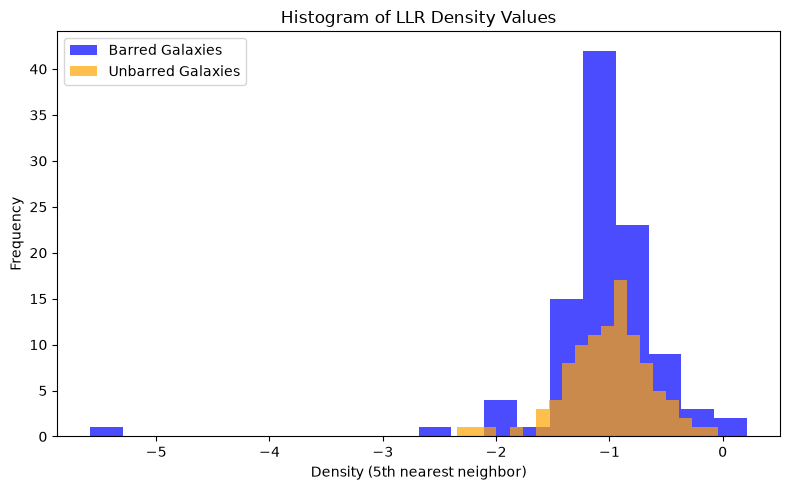

In [17]:
plt.figure(figsize=(8, 5))
plt.hist((llr_dens[:, 0][llr_dens[:, -1] == 'barred'].astype(np.float64)), bins=20, label='Barred Galaxies', color='blue', alpha=0.7)
plt.hist((llr_dens[:, 0][llr_dens[:, -1] == 'unbarred'].astype(np.float64)), bins=20, label='Unbarred Galaxies', color='orange', alpha=0.7)
plt.xlabel('Density (5th nearest neighbor)')
plt.ylabel('Frequency')
plt.title('Histogram of LLR Density Values')
plt.legend()
plt.tight_layout()
plt.savefig(f'../fig/llr_density_histogram.png', dpi=300)
plt.show()

In [ ]:
# dens = []
# for i, idx in enumerate(xgb_arr):
#     if idx == -999:
#         continue
#     idx = int(idx)
#     file_list = glob.glob(f'../data/catalog/ps1/merged/t{tg_ra[i]:08.4f}{tg_dec[i]:+07.4f}.csv')
#     if len(file_list) == 0:
#         continue
#     df = pd.read_csv(file_list[0])
#     if idx >= len(df):
#         continue
#     row = df.distance.iloc[idx] / 60
#     row = np.deg2rad(row)
#     fifth_dis = row * tg_d[i]
#     if fifth_dis <= 0 or not np.isfinite(fifth_dis):
#         continue
#     fifth_dens = 5 / np.pi / fifth_dis**2
#     fifth_dens = np.log(fifth_dens)
#     dens.append(fifth_dens)


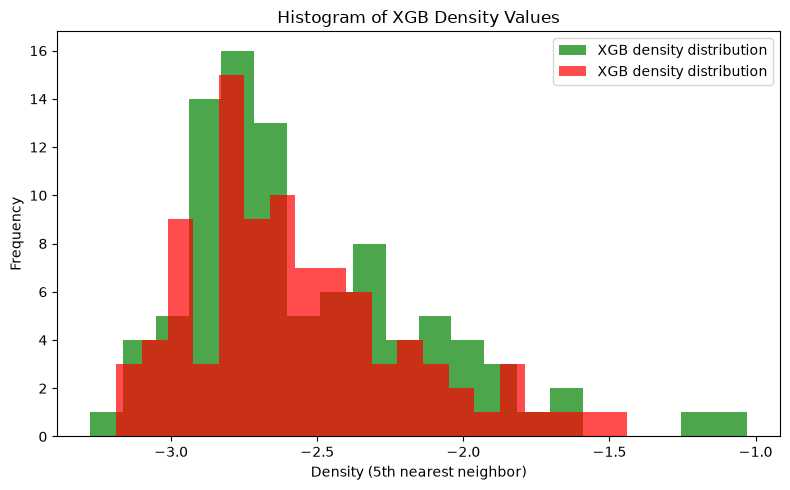

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(xgb_dens[:, 0][xgb_dens[:, -1] == 'barred'].astype(np.float64), bins=20, label='XGB density distribution', color='green', alpha=0.7)
plt.hist(xgb_dens[:, 0][xgb_dens[:, -1] == 'unbarred'].astype(np.float64), bins=20, label='XGB density distribution', color='red', alpha=0.7)
plt.xlabel('Density (5th nearest neighbor)')
plt.ylabel('Frequency')
plt.title('Histogram of XGB Density Values')
plt.legend()
plt.tight_layout()
plt.savefig(f'../fig/xgb_density_histogram.png', dpi=300)
plt.show()

In [ ]:
# dens = []
# for i, idx in enumerate(llr_filtered_arr):
#     if idx == -999:
#         continue
#     idx = int(idx)
#     file_list = glob.glob(f'../data/catalog/ps1/merged/t{tg_ra[i]:08.4f}{tg_dec[i]:+07.4f}.csv')
#     if len(file_list) == 0:
#         continue
#     df = pd.read_csv(file_list[0])
#     if idx >= len(df):
#         continue
#     row = df.distance.iloc[idx] / 60
#     row = np.deg2rad(row)
#     fifth_dis = row * tg_d[i]
#     if fifth_dis <= 0 or not np.isfinite(fifth_dis):
#         continue
#     fifth_dens = 5 / np.pi / fifth_dis**2
#     fifth_dens = np.log(fifth_dens)
#     dens.append(fifth_dens)

In [ ]:
# plt.figure(figsize=(8, 5))
# plt.hist(llr_filtered_dens, bins=10, label='LLR filtered density distribution', color='orange', alpha=0.7)
# plt.xlabel('Density (5th nearest neighbor)')
# plt.ylabel('Frequency')
# plt.title('Histogram of LLR Filtered Density Values')
# plt.legend()
# plt.tight_layout()
# plt.savefig(f'../fig/llr_filtered_density_histogram_{len(glob.glob("../fig/*.png"))}.png', dpi=300)
# plt.show()

In [ ]:
# dens = []
# for i, idx in enumerate(xgb_filtered_arr):
#     if idx == -999:
#         continue
#     idx = int(idx)
#     file_list = glob.glob(f'../data/catalog/ps1/merged/t{tg_ra[i]:08.4f}{tg_dec[i]:+07.4f}.csv')
#     if len(file_list) == 0:
#         continue
#     df = pd.read_csv(file_list[0])
#     if idx >= len(df):
#         continue
#     row = df.distance.iloc[idx] / 60
#     row = np.deg2rad(row)
#     fifth_dis = row * tg_d[i]
#     if fifth_dis <= 0 or not np.isfinite(fifth_dis):
#         continue
#     fifth_dens = 5 / np.pi / fifth_dis**2
#     fifth_dens = np.log(fifth_dens)
#     dens.append(fifth_dens)


In [ ]:
# plt.figure(figsize=(8, 5))
# plt.hist(xgb_filtered_dens, bins=10, label='XGB filtered density distribution', color='purple', alpha=0.7)
# plt.xlabel('Density (5th nearest neighbor)')
# plt.ylabel('Frequency')
# plt.title('Histogram of XGB Filtered Density Values')
# plt.legend()
# plt.tight_layout()
# plt.savefig(f'../fig/xgb_filtered_density_histogram_{len(glob.glob("../fig/*.png"))}.png', dpi=300)
# plt.show()

In [ ]:
dens_df = pd.DataFrame()
for m in model:
    def compute_index_for_i(i):
        file_list = glob.glob(f'../data/catalog/ps1/merged/t{tg_ra[i]:08.4f}{tg_dec[i]:+07.4f}.csv')
        if len(file_list) == 0:
            return -999

        target_z = float(target.paliya_Z.iloc[i])
        df = pd.read_csv(file_list[0])

        z_window = (
            z_at_value(Planck18.comoving_distance, (tg_d[i] + 5) * u.Mpc)
            - z_at_value(Planck18.comoving_distance, (tg_d[i] - 5) * u.Mpc)
        )
        # df = df[np.isfinite(df.z_phot0) & np.isfinite(df.z_photErr)]
        # df = df[np.abs(df.z_phot0 - target_z) < z_window]

        if len(df) == 0:
            return -999

        surround_z = df[f'z_phot{col[m]}'].to_numpy(dtype=float)
        surround_err = df[f'z_phot_err{col[m]}'].to_numpy(dtype=float)
        surround_ra = df.raMean.to_numpy(dtype=float)
        surround_dec = df.decMean.to_numpy(dtype=float)

        mask = (surround_z - surround_err / 2) > -1
        surround_z = surround_z[mask]
        surround_err = surround_err[mask]
        surround_ra = surround_ra[mask]
        surround_dec = surround_dec[mask]

        if len(surround_z) == 0:
            return -999

        surround_d = Planck18.comoving_distance(surround_z).value
        valid = np.isfinite(surround_d) & (surround_d >= 0)
        surround_z = surround_z[valid]
        surround_err = surround_err[valid]
        surround_ra = surround_ra[valid]
        surround_dec = surround_dec[valid]
        surround_d = surround_d[valid]

        if len(surround_d) == 0:
            return -999

        z_low = np.maximum(surround_z - surround_err / 2, 0)
        surround_scale = (
            Planck18.comoving_distance(surround_z + surround_err / 2)
            - Planck18.comoving_distance(z_low)
        ).value
        surround_odds = np.abs(
            norm.cdf(Planck18.comoving_distance(tg_z[i] - 1000/300000), loc=surround_d, scale=surround_scale)
            - norm.cdf(Planck18.comoving_distance(tg_z[i] + 1000/300000), loc=surround_d, scale=surround_scale)
        )

        coord_1 = SkyCoord(ra=surround_ra * u.deg, dec=surround_dec * u.deg, distance=surround_d * u.Mpc)
        target_coord = coord[i]

        df_surround = target_coord.separation(coord_1)
        df_surround = df_surround.to_value(u.rad) * tg_d[i]
        X = np.asarray(df_surround, dtype=float).reshape(-1, 1)
        nn = NearestNeighbors(n_neighbors=max(1, min(int(len(X) / 2), len(X))), algorithm='auto')
        nn.fit(X)
        neighbors = nn.kneighbors(np.array([[0]]))
        k_index = np.where(np.cumsum(surround_odds[neighbors[1][0]]) >= 5)[0]
        if len(k_index) == 0:
            return -999

        index = neighbors[1][0][:k_index[0]]
            
        row = df.distance.iloc[index] / 60
        row = np.deg2rad(row)
        fifth_dis = row * tg_d[i]
        fifth_dis = (fifth_dis**2) * surround_odds[index]
        fifth_dens = np.sum(surround_odds[index]) / np.pi / np.sum(fifth_dis)
        fifth_dens = np.log(fifth_dens)
        return fifth_dens

    dens = np.array(Parallel(n_jobs=-1, verbose=5)(delayed(compute_index_for_i)(i) for i in range(len(tg_df))))
    dens_df[f'dens_{m}'] = [dens]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  84 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done 202 out of 202 | elapsed:    7.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done 110 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 183 out of 202 | elapsed:    2.5s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done 202 out of 202 | elapsed:    2.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  84 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 202 out of 202 | elapsed:    7.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done 110 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done 183 out of 202 | elapsed:    2.5s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done 202 out of 202 | elapsed:    2.7s finishe